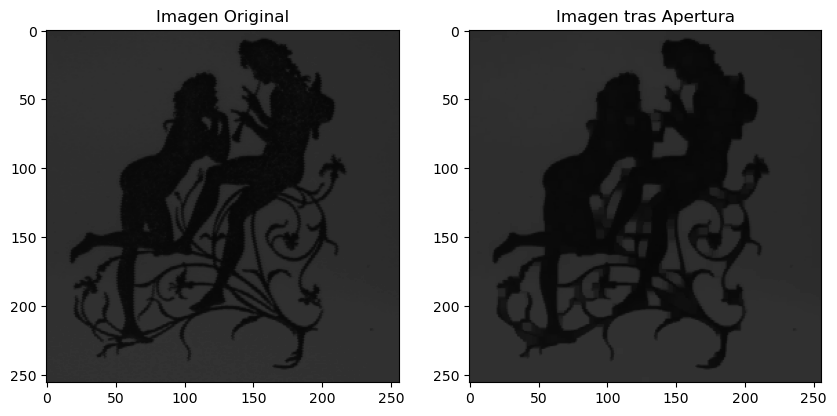

In [8]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

amour = cv2.imread('AMOUR.png', cv2.IMREAD_GRAYSCALE)
mascara = np.ones((5, 5), np.uint8)
amourM = cv2.morphologyEx(amour, cv2.MORPH_OPEN, mascara)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(amour, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen Original")
plt.subplot(1, 2, 2)
plt.imshow(amourM, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen tras Apertura")
plt.show()

### ¿Qué partes fueron suprimidas?

Al utilizar la opreación de apertura con la mascara podemos ver que se suprimieron todos los detalles que componen los bordes de la imagen, el cambio es más evidente en los detalles de las siluetas y los espacios pequeños que desaparecen.

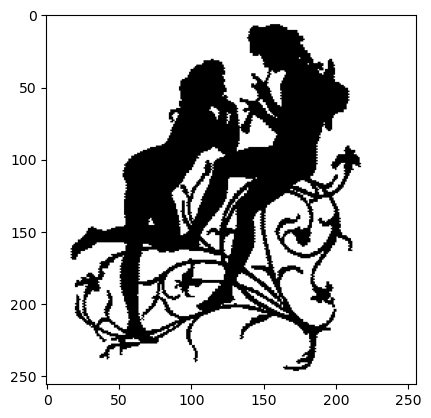

In [9]:
umbral = 35
_, amourU = cv2.threshold(amour, umbral, 255, cv2.THRESH_BINARY)
plt.imshow(amourU, cmap='gray', vmin=0, vmax=255)
plt.show()

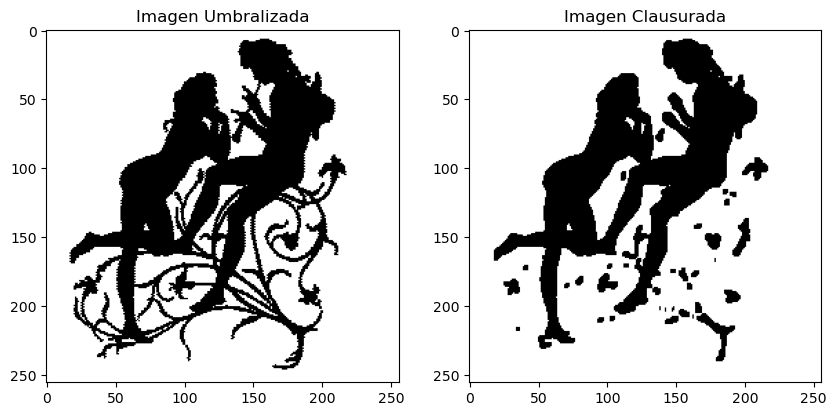

In [10]:
m1 = np.eye(3, dtype=np.uint8)
m2 = np.fliplr(m1)
m3 = np.ones((1, 3), dtype=np.uint8)
m4 = np.ones((3, 1), dtype=np.uint8)
amourC = cv2.morphologyEx(amourU, cv2.MORPH_CLOSE, m1)
amourC = cv2.morphologyEx(amourC, cv2.MORPH_CLOSE, m2)
amourC = cv2.morphologyEx(amourC, cv2.MORPH_CLOSE, m3)
amourC = cv2.morphologyEx(amourC, cv2.MORPH_CLOSE, m4)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(amourU, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen Umbralizada")
plt.subplot(1, 2, 2)
plt.imshow(amourC, cmap='gray', vmin=0, vmax=255)
plt.title("Imagen Clausurada")
plt.show()


### ¿Cuál es el efecto obtenido?

Parece ser que al aplicar el cierre, los detalles más finos y desgados desaparecen, pero se conservan los que son suficientemente gruesos.

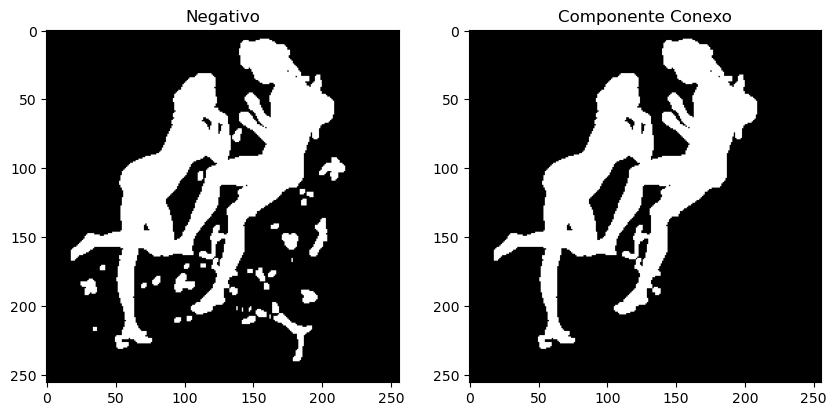

In [11]:
from skimage.measure import label, regionprops

amourN = 255 - amourC
componentes = label(amourN, background=0, connectivity=2)
props = regionprops(componentes)
mayor_componente = max(props, key=lambda x: x.area)
amourCC = np.zeros_like(componentes, dtype=np.uint8)
amourCC[componentes == mayor_componente.label] = 255

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(amourN, cmap='gray', vmin=0, vmax=255)
plt.title("Negativo")
plt.subplot(1, 2, 2)
plt.imshow(amourCC, cmap='gray', vmin=0, vmax=255)
plt.title("Componente Conexo")
plt.show()


### ¿Cuál es el resultado?

El negativo de la imagen invierte los colores para que la aimagen cambie a tener un fondo negro con objetos blancos. Luego se detectan los componentes conexos y se selecciona el de mayor tamaño. Entonces el resultado es unicamente las siluetas de las personas con un poco de los residuos de los demás componentes de la imagen que no pudieron ser totalmente eliminados en el proceso.